This is the Quality control step of crc-pm

In [13]:
# modules
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scipy as sp
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from pathlib import Path
import anndata as ad
import sys
import re
import os
import seaborn as sns
import scvi
### Import personal Utensils
sys.path.insert(0, "..")
import utils as ut

In [14]:
# read data
CuratedDir = Path("../../result/curated/merged.h5ad")
adata = sc.read_h5ad(CuratedDir)
# use raw counts
adata.X = adata.layers["counts"].copy()
ut.preview_adata(adata)

shape: (90603, 17138)
X: csr_matrix, sparse=True, dtype=int32
unique index: obs=True, var=True
obs:
  Study: category n_unique=3 {'crc01': np.int64(43841), 'crc06': np.int64(28661), 'crc03': np.int64(18101)}
  Sample: category n_unique=37 top=['pm1', 'B_crc', 'B_pm', 'C_pm', 'PC1']
  Tech: category n_unique=2 {'scRNA': np.int64(61942), 'snRNA': np.int64(28661)}
  Glob_CellID: object n_unique=90603 top=['crc03-CRC2_AAACATCGACTATGCAACATTGGC', 'crc03-CRC2_AAACATCGAGATGTACCGACACAC', 'crc03-CRC2_AAACATCGCAATGGAAAGTACAAG', 'crc03-CRC2_AAACATCGCGCATACACCTCTATC', 'crc03-CRC2_AAACATCGTAGGATGAACCTCCAA']
  Glob_Sample: category n_unique=37 top=['crc01-pm1', 'crc06-B_crc', 'crc06-B_pm', 'crc06-C_pm', 'crc03-PC1']
  Tissue: category n_unique=2 {'pm': np.int64(60349), 'crc': np.int64(30254)}
  Patient: category n_unique=17 top=['patient1', 'B', 'patient3', 'patient4', 'patient10']
  Glob_Patient: category n_unique=21 top=['crc01-patient1', 'crc06-B', 'crc01-patient10', 'crc06-C', 'crc03-patient1']
v

### Remove ambient RNA

In [15]:
# gentle QC
sc.pp.filter_cells(adata, min_counts=400)
sc.pp.filter_cells(adata, min_genes=100)

# scAR removal of ambient RNA
denoised_rna = adata.layers["counts"].copy().tolil()
for study in ["crc01", "crc03", "crc06"]:
    mask = adata.obs["Study"] == study
    idx = np.flatnonzero(mask.to_numpy())
    sub = adata[idx].copy()
    scvi.external.SCAR.setup_anndata(sub,batch_key="Glob_Sample")
    model = scvi.external.SCAR(sub,ambient_profile=None)
    model.train(accelerator="gpu")
    denoised = model.get_denoised_counts()
    # write results into the corresponding rows of the full matrix
    denoised_rna[idx, :] = csr_matrix(denoised)
    print(f"{study} done: {denoised.shape}")
# save back to the original AnnData and to .X
adata.layers["denoised_rna"] = denoised_rna.tocsr()
adata.X = adata.layers["denoised_rna"].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-

Training:   0%|          | 0/183 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=183` reached.


crc01 done: (43833, 17138)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/zhekai/miniconda3/envs/pm/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training:   0%|          | 0/290 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=290` reached.


crc06 done: (27624, 17138)


SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

### Coarse QC

In [16]:
# Define var
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

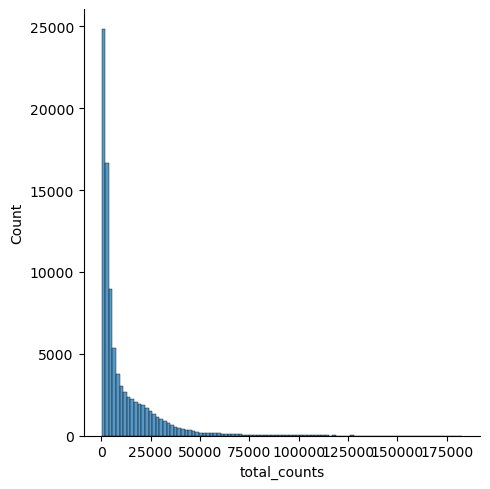

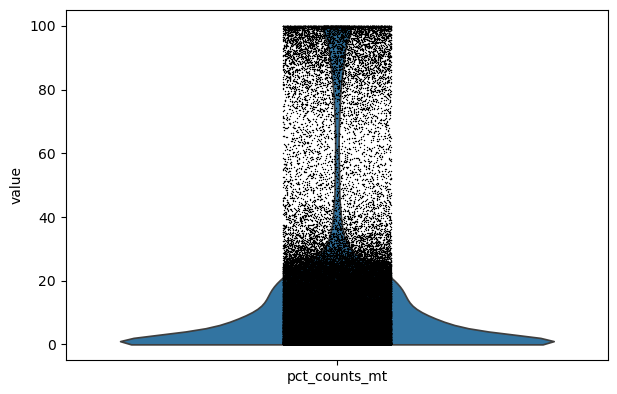

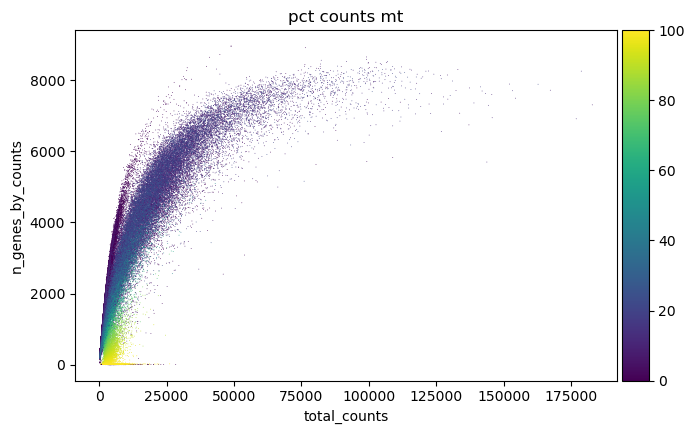

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

In [17]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

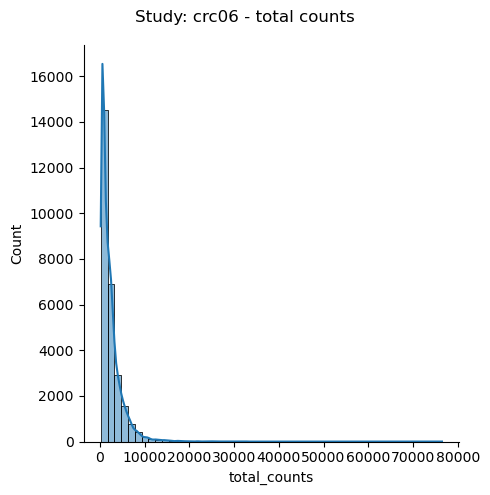

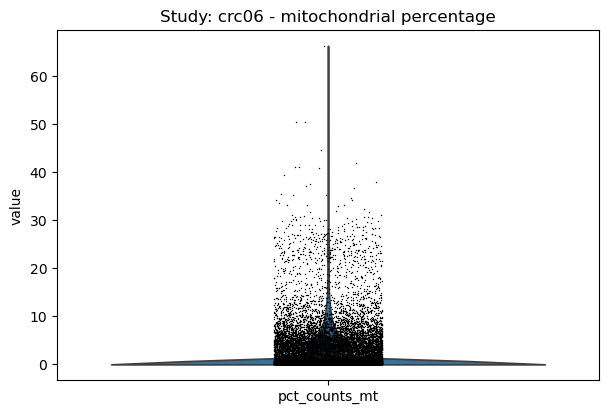

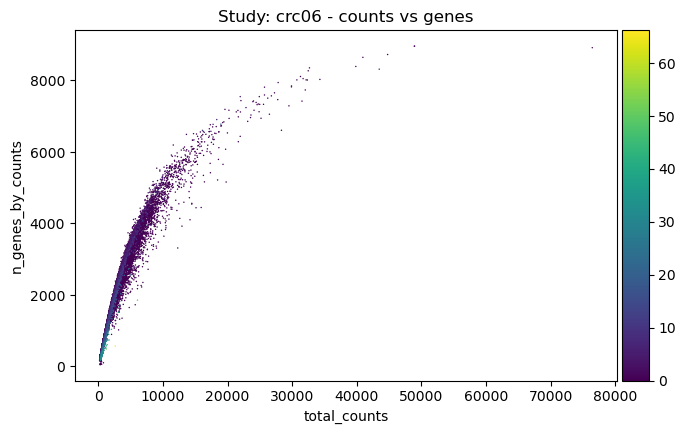

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

In [18]:
# Preview data quality by sample (helper in utils)
ut.preview_cell_quality(adata, "Study",'crc06')

In [19]:
def is_outlier(adata, metric: str, nmads: int, groupby):
    M = adata.obs[metric]
    grouped = adata.obs.groupby(groupby,observed=True)[metric]
    median = grouped.transform("median")
    mad = grouped.transform(lambda x: median_abs_deviation(x, nan_policy="omit"))
    outlier = ((M < median - nmads * mad) | (M > median + nmads * mad))
    return outlier

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

In [20]:
# cell filtering
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5, groupby="Glob_Sample")
    | is_outlier(adata, "log1p_n_genes_by_counts", 5, groupby="Glob_Sample")
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5, groupby="Glob_Sample")
)
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3, groupby="Glob_Sample") | (
    adata.obs["pct_counts_mt"] > 40)
# very hard to choose the mt threshold, as lots of cells in crc01 have high mt percentage
# while in crc06, almost no mt percentage
# it is so decided that 40% should be should be the threshold

print(adata.obs.mt_outlier.value_counts())
print(adata.obs.outlier.value_counts())

mt_outlier
False    69942
True     19434
Name: count, dtype: int64
outlier
False    82273
True      7103
Name: count, dtype: int64


SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

Total number of cells: 89376
Number of cells after filtering of low quality cells: 66934


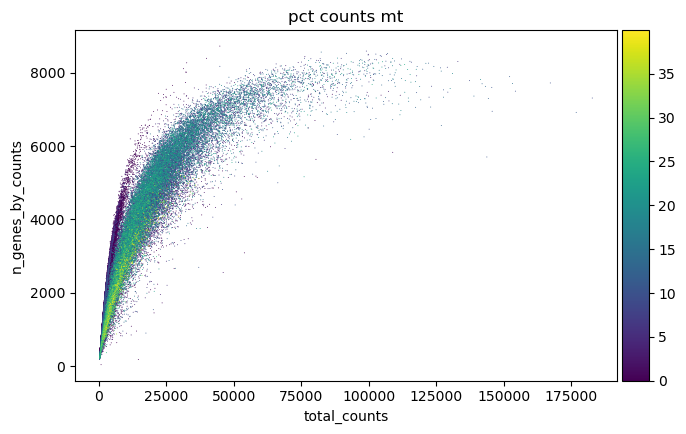

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

In [21]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [22]:
# gene filtering
sc.pp.filter_genes(adata, min_cells=20)

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

### Doublet depletion

In [23]:
adata.obs["Study_Tissue"] = adata.obs["Study"].astype(str) + "_" + adata.obs["Tissue"].astype(str)
sc.pp.scrublet(
    adata,
    batch_key="Study_Tissue",
    expected_doublet_rate=0.05,
    random_state=0,
)
# here we use study_tissue as batch_key, because fucking crc01 contains some sample which literally has no fucking cells

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

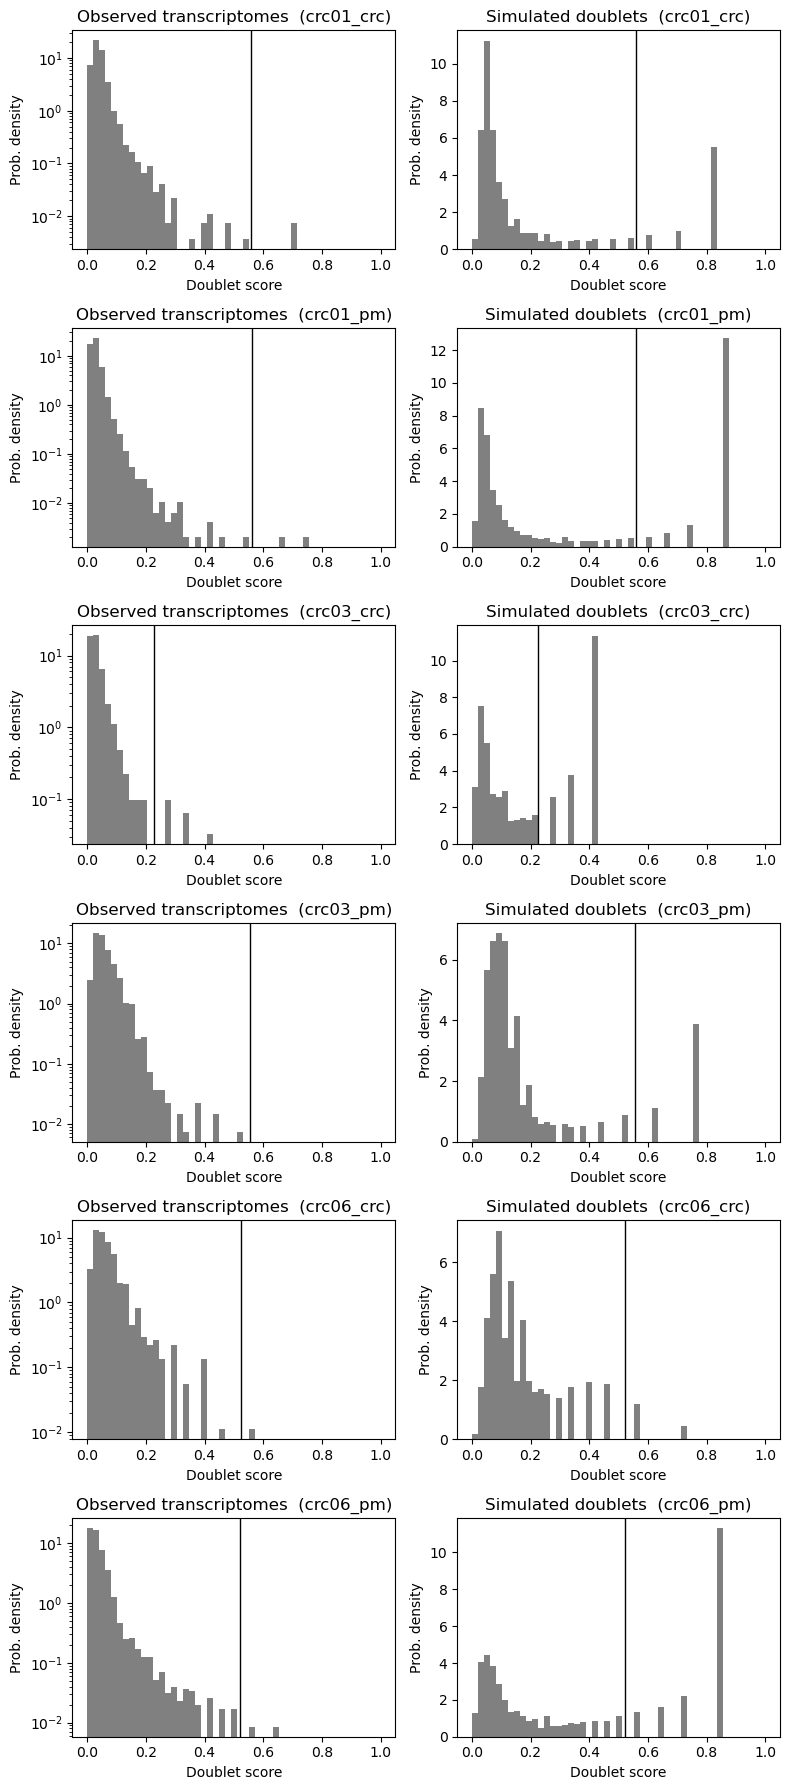

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained

In [24]:
sc.pl.scrublet_score_distribution(adata)

### Export

In [25]:
adata = adata[~adata.obs["predicted_doublet"]].copy()
outdir = Path("../../result/qc")
adata.write_h5ad(outdir / "qc.h5ad", compression="lzf")

SCVI-AR Model with the following params: 
n_hidden: 150, n_latent: 15, n_layers: 2, dropout_rate: 0.0, gene_likelihood: b, latent_distribution: normal
Training status: Trained